MobileNet: This lightweight architecture is ideal for mobile and embedded devices, balancing performance and efficiency.
GlobalAveragePooling2D: Reduces the feature map into a single vector by averaging spatial dimensions, reducing the number of parameters.
Dense Layers: Additional fully connected layers are added for classification.
Binary Classification: The sigmoid activation is used for binary output (detecting the presence or absence of osteoporosis).


1. The dataset should be organized as follows:

dataset/
    train/
        normal/        # Normal bone density images (class 0)
        osteoporosis/  # Osteoporosis images (class 1)
    validation/
        normal/
        osteoporosis/
    test/
        normal/
        osteoporosis/


In [1]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import cv2  # To display text on the image
from PIL import Image

2. Modify Data Loading with ImageDataGenerator:
   Since you are now working with three classes, use class_mode='categorical' for multi-class classification:

In [2]:

# ImageDataGenerator for data augmentation and normalization
train_datagen = ImageDataGenerator(rescale=1./255,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True)

val_datagen = ImageDataGenerator(rescale=1./255)

# Load the training set
train_generator = train_datagen.flow_from_directory(
    'dataset/train',  # Path to training dataset
    target_size=(224, 224),  # Resize images to 224x224
    batch_size=32,
    class_mode='categorical'  # Categorical for multi-class (normal, osteoporosis, osteopenia)
)

# Load the validation set
validation_generator = val_datagen.flow_from_directory(
    'dataset/validation',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'  # Categorical for multi-class classification
)

# Optionally, load the test set for evaluation
test_generator = val_datagen.flow_from_directory(
    'dataset/test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)


Found 1947 images belonging to 2 classes.
Found 1947 images belonging to 2 classes.
Found 829 images belonging to 2 classes.


3. Update the Model for Multi-Class Classification:
Since you have three classes, modify the output layer and use softmax activation for multi-class classification.

In [3]:
# Load the MobileNet model pre-trained on ImageNet, excluding the top fully connected layers
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers (optional, for fine-tuning)
for layer in base_model.layers:
    layer.trainable = False

# Add custom layers on top of the base MobileNet model
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Add global average pooling to reduce dimensions
x = Dense(1024, activation='relu')(x)  # Add a fully connected layer
x = Dense(512, activation='relu')(x)  # Another fully connected layer
x = Dense(128, activation='relu')(x)  # Another fully connected layer

# Update the final output layer for 3 classes
predictions = Dense(2, activation='softmax')(x)  # 3 output neurons for 3 classes (normal, osteoporosis, osteopenia)

# Combine the base model and the custom layers
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model with categorical crossentropy for multi-class classification
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',  # Multi-class loss function
              metrics=['accuracy'])

# ImageDataGenerator for data augmentation and normalization
train_datagen = ImageDataGenerator(rescale=1./255, 
                                   shear_range=0.2, 
                                   zoom_range=0.2, 
                                   horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

# Load training and validation datasets
train_generator = train_datagen.flow_from_directory(
    'dataset/train',  # Path to your training dataset
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'  # Multi-class classification (normal, osteoporosis, osteopenia)
)

validation_generator = val_datagen.flow_from_directory(
    'dataset/validation',  # Path to your validation dataset
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'  # Multi-class classification
)

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=100
)


Found 1947 images belonging to 2 classes.
Found 1947 images belonging to 2 classes.
Epoch 1/100


e:\DrBones\Dr_Bones\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


60/60 ━━━━━━━━━━━━━━━━━━━━ 247s 4s/step - accuracy: 0.7234 - loss: 0.5379 - val_accuracy: 0.8385 - val_loss: 0.3888
Epoch 2/100
 1/60 ━━━━━━━━━━━━━━━━━━━━ 28s 487ms/step - accuracy: 0.9062 - loss: 0.3153

D:\anaconda\Lib\contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9062 - loss: 0.3153 - val_accuracy: 0.8889 - val_loss: 0.3159
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 186s 3s/step - accuracy: 0.8320 - loss: 0.3988 - val_accuracy: 0.8214 - val_loss: 0.4021
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8125 - loss: 0.4436 - val_accuracy: 0.8148 - val_loss: 0.4376
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 186s 3s/step - accuracy: 0.8395 - loss: 0.3505 - val_accuracy: 0.8823 - val_loss: 0.2965
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8438 - loss: 0.3914 - val_accuracy: 0.8889 - val_loss: 0.2794
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 180s 3s/step - accuracy: 0.8733 - loss: 0.3096 - val_accuracy: 0.8750 - val_loss: 0.2926
Epoch 8/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7500 - loss: 0.5306 - val_accuracy: 0.8889 - val_loss: 0.1959
Epoch 9/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 180s 3s/step - accuracy: 0.8789 - loss: 0.3197 - val_accuracy: 0.8984 - val_l

In [4]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 8,149,832 (31.09 MB)

 Trainable params: 1,640,322 (6.26 MB)

 Non-trainable params: 3,228,864 (12.32 MB)

 Optimizer params: 3,280,646 (12.51 MB)

4. Evaluating the Model:

In [5]:
# Test data generator (only rescaling)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load test dataset
test_generator = test_datagen.flow_from_directory(
    'dataset/test',  # Path to your test dataset
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'  # Multi-class classification
)

# Evaluate the model on test data
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test accuracy: {test_acc}')


Found 829 images belonging to 2 classes.
26/26 ━━━━━━━━━━━━━━━━━━━━ 22s 841ms/step - accuracy: 0.9256 - loss: 0.1480
Test accuracy: 0.9324487447738647


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step


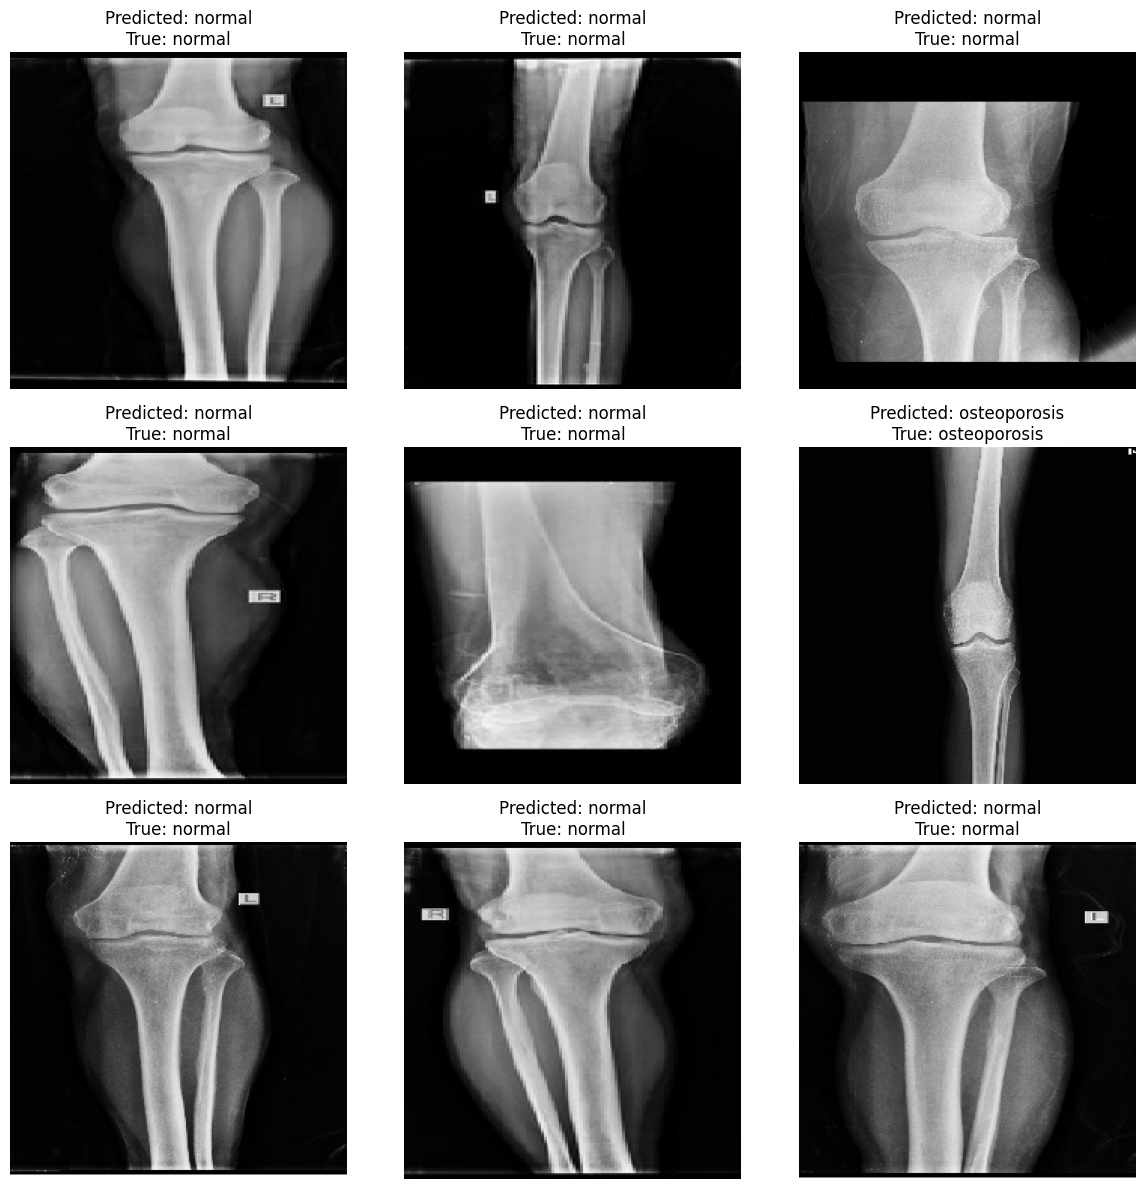

In [7]:
# Get the class indices for reference
class_indices = test_generator.class_indices
class_labels = list(class_indices.keys())

# Get a batch of images and labels from the test generator
images, labels = next(test_generator)

# Make predictions
predictions = model.predict(images)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(labels, axis=1)

# Plot the images along with their predicted and true labels
plt.figure(figsize=(12, 12))

for i in range(9):  # Display first 9 images
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    plt.title(f'Predicted: {class_labels[predicted_classes[i]]}\nTrue: {class_labels[true_classes[i]]}')
    plt.axis('off')

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step


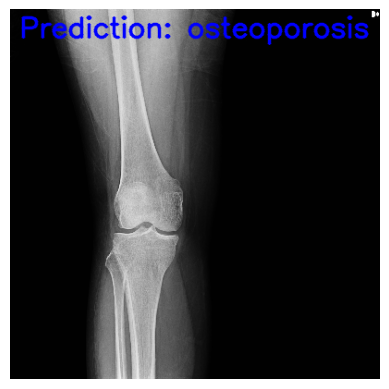

In [8]:
from tensorflow.keras.preprocessing import image  # Import the image module
from tensorflow.keras.applications.mobilenet import preprocess_input

# Function to predict and display image with label
def predict_and_display_image(model, img_path, class_labels):
    # Load the image and resize it to the input size expected by the model (224x224 for MobileNet)
    img = image.load_img(img_path, target_size=(224, 224))
    
    # Convert the image to a numpy array and preprocess it
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)  # Preprocess the image like the model expects (e.g., scaling)

    # Predict the class probabilities
    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions, axis=1)[0]
    
    # Get the predicted label
    predicted_label = class_labels[predicted_class]
    
    # Load the original image to display
    original_img = cv2.imread(img_path)
    original_img = cv2.resize(original_img, (400, 400))  # Resize for display purposes
    
    # Display the predicted label on the image
    cv2.putText(original_img, f'Prediction: {predicted_label}', (10, 30), 
                cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2, cv2.LINE_AA)

    # Convert color back to RGB (since OpenCV uses BGR by default)
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

    # Display the image with the predicted label
    plt.imshow(original_img)
    plt.axis('off')  # Hide axis
    plt.show()

# Example usage:
# Assuming you have a trained model and test_generator already set up
class_labels = list(test_generator.class_indices.keys())  # Class labels from the test generator

# Path to the image you want to test
image_path = r'E:\DrBones\dataset\test\osteoporosis\OS37.jpg'

# Call the function with the model, image path, and class labels
predict_and_display_image(model, image_path, class_labels)


In [9]:
# Save the model
model.save('DrBones.h5')

Loading the MobileNet Model
To load the saved model later, use the following code:

from tensorflow.keras.models import load_model

# Load the model
loaded_model = load_model('mobilenet_model.h5')

# Use the loaded model for predictions
predictions = loaded_model.predict(X_test)  # Replace X_test with your input data